In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [9]:
df = pd.read_excel(r"C:\Users\Admin\Downloads\House_Price_Prediction_Dataset.xlsx")

In [10]:
df.head()
df.tail()

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age,Price
195,HouseID_196,2271,4,3,28,12025800
196,HouseID_197,1831,4,4,30,10037400
197,HouseID_198,1794,3,3,24,9585329
198,HouseID_199,2705,5,5,18,15169934
199,HouseID_200,2113,5,5,15,12081304


In [11]:
df.shape
df.columns

Index(['House_ID', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Price'], dtype='object')

In [12]:
#Data Cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   House_ID   200 non-null    object
 1   Area_sqft  200 non-null    int64 
 2   Bedrooms   200 non-null    int64 
 3   Bathrooms  200 non-null    int64 
 4   Age        200 non-null    int64 
 5   Price      200 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 9.5+ KB


In [13]:
df.isnull().sum()

House_ID     0
Area_sqft    0
Bedrooms     0
Bathrooms    0
Age          0
Price        0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop("House_ID",axis=1,inplace=True)

In [19]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age,Price
count,200.000000,200.00000,200.000000,200.000000,2.000000e+02
mean,1901.930000,3.71500,3.235000,15.660000,1.055925e+07
std,644.706333,1.46441,1.378141,8.730723,3.743129e+06
min,701.000000,1.00000,1.000000,1.000000,3.457886e+06
25%,1429.500000,3.00000,2.000000,8.000000,7.613960e+06
50%,1881.000000,4.00000,3.000000,15.000000,1.040411e+07
75%,2438.250000,5.00000,4.000000,23.000000,1.369699e+07
max,2981.000000,6.00000,5.000000,30.000000,1.693576e+07


In [20]:
df.corr()

,Area_sqft,Bedrooms,Bathrooms,Age,Price
Area_sqft,1.000000,0.920764,0.879666,0.080168,0.996846
Bedrooms,0.920764,1.000000,0.939695,0.081209,0.933125
Bathrooms,0.879666,0.939695,1.000000,0.017533,0.898771
Age,0.080168,0.081209,0.017533,1.000000,0.021337
Price,0.996846,0.933125,0.898771,0.021337,1.000000


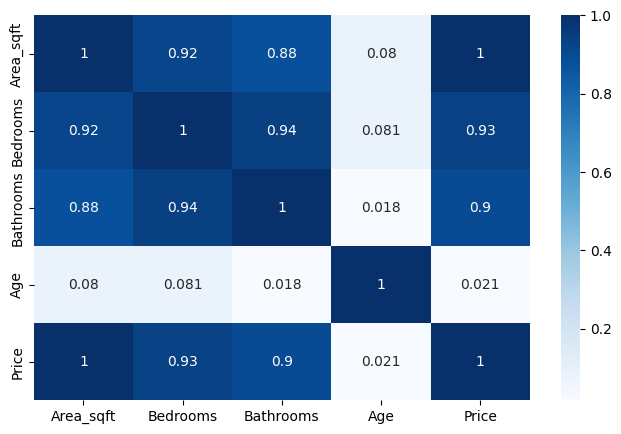

In [21]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.show()

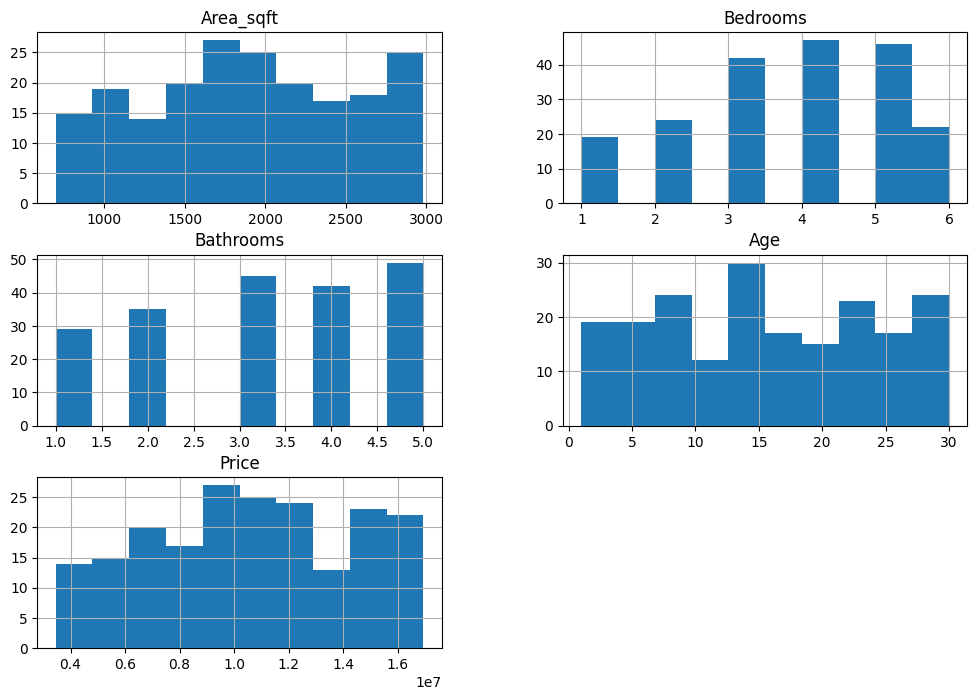

In [22]:
df.hist(figsize=(12,8))
plt.show()

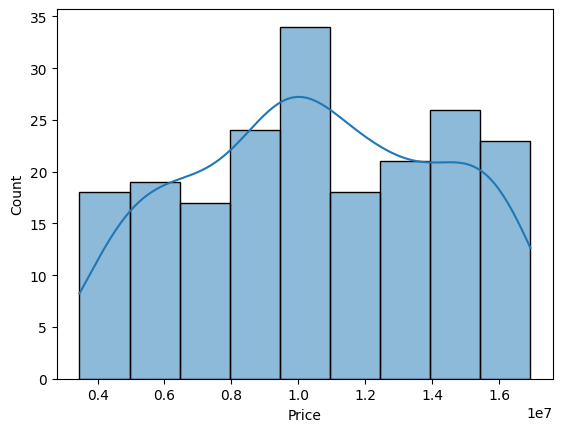

In [23]:
sns.histplot(df["Price"], kde=True)
plt.show()

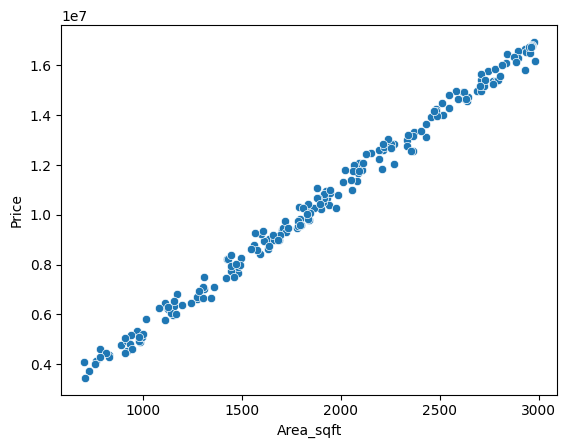

In [24]:
sns.scatterplot(x="Area_sqft",
                y="Price",
                data=df)

plt.show()

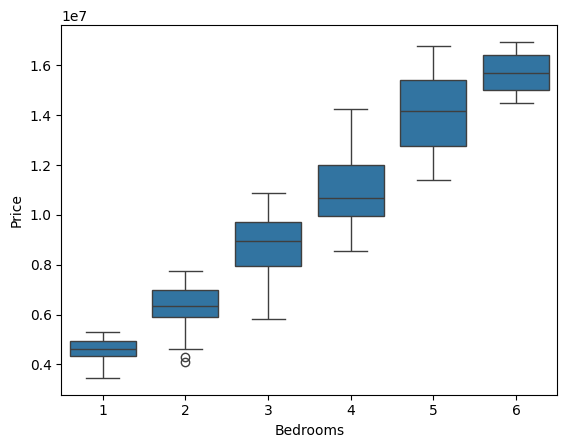

In [25]:
sns.boxplot(x="Bedrooms",
            y="Price",
            data=df)

plt.show()

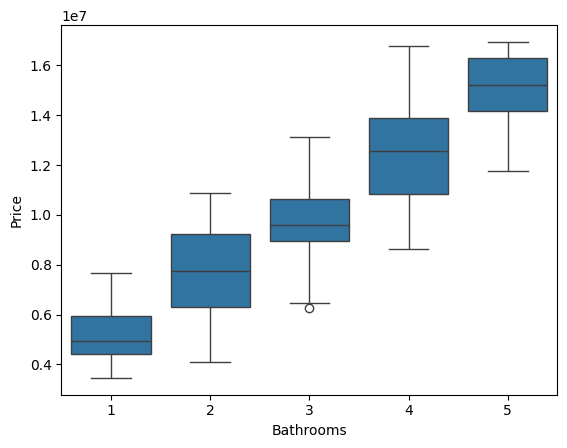

In [26]:
sns.boxplot(x="Bathrooms",
            y="Price",
            data=df)

plt.show()

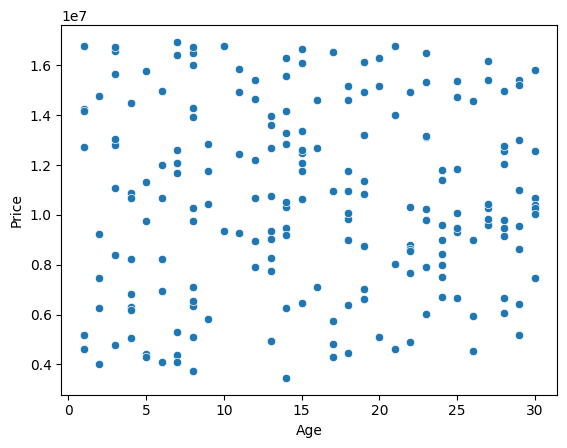

In [27]:
sns.scatterplot(
    x="Age",
    y="Price",
    data=df
)
plt.show()

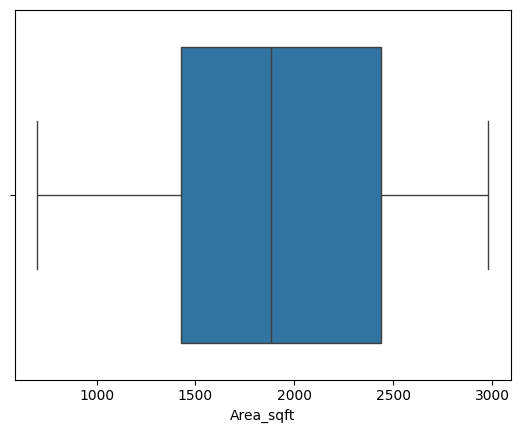

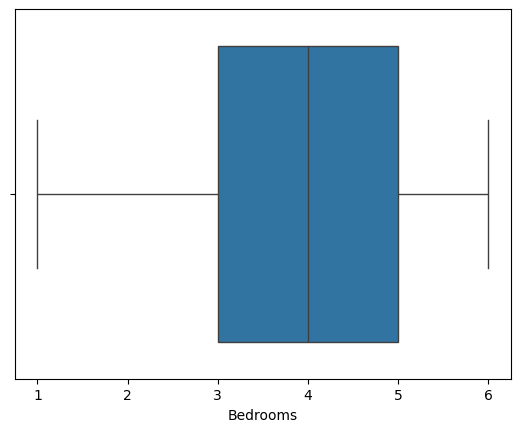

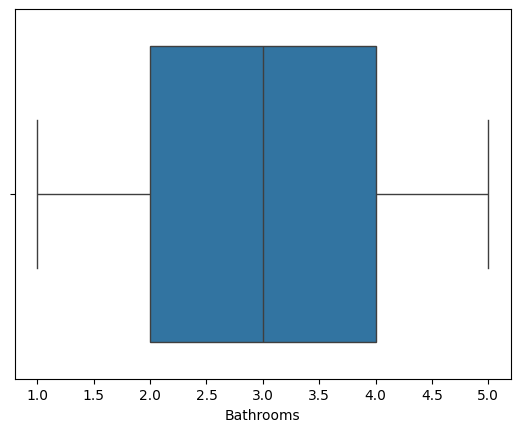

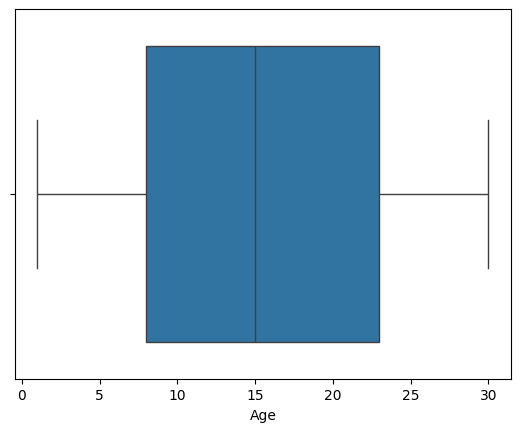

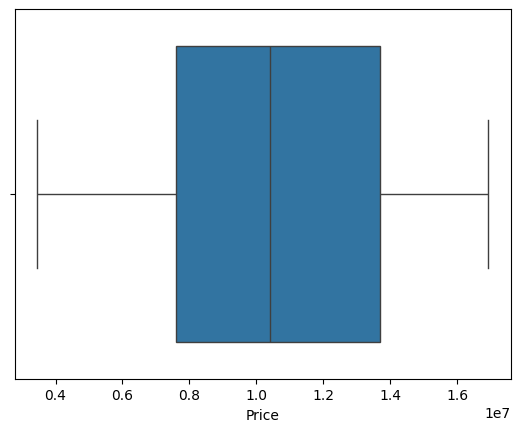

In [28]:
for col in df.columns:
    sns.boxplot(x=df[col])
    plt.show()

In [29]:
df.head(2)

,Area_sqft,Bedrooms,Bathrooms,Age,Price
0,1156,2,2,8,6328226
1,1271,2,1,19,6635408


In [44]:
X = df[["Area_sqft","Bedrooms","Bathrooms"]]
y = df['Price']
X.head()

,Area_sqft,Bedrooms,Bathrooms
0,1156,2,2
1,1271,2,1
2,830,1,1
3,2769,5,4
4,2932,6,5


In [43]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [37]:
model = LinearRegression()

In [45]:
model.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_pred = model.predict(X_test)


In [47]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
95,10515814,1.030222e+07
15,9366930,9.400755e+06
30,7087411,7.332004e+06
158,14946075,1.505338e+07
128,5105722,5.058698e+06
115,13301445,1.345958e+07
69,16790305,1.659086e+07
170,11061387,1.061457e+07
174,10652465,1.043031e+07
45,4945993,4.743996e+06


In [48]:
mean_absolute_error(y_test, y_pred)

194956.23648461254

In [49]:
mean_squared_error(y_test, y_pred)

54643771681.83264

In [50]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(233760.07289918576)

In [51]:
r2_score(y_test, y_pred)

0.9960583970179963

In [52]:
print(model.coef_)

[  5245.02134505  85449.02741882 194749.36191207]


In [53]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})


,Feature,Coefficient
0,Area_sqft,5245.021345
1,Bedrooms,85449.027419
2,Bathrooms,194749.361912


In [54]:
model.intercept_

np.float64(-366866.56069675274)

In [56]:
new_house = [[1500, 3, 2]]

prediction = model.predict(new_house)

print(prediction)

[8146511.26296003]


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [63]:
new_house = [[1500, 3, 2]]

prediction = model.predict(new_house)

print("House Details")
print("-" * 30)
print("Area       :", new_house[0][0], "sqft")
print("Bedrooms   :", new_house[0][1])
print("Bathrooms  :", new_house[0][2])
print("\nPredicted House Price: ₹{:,.2f}".format(prediction[0]))

House Details
------------------------------
Area       : 1500 sqft
Bedrooms   : 3
Bathrooms  : 2

Predicted House Price: ₹8,146,511.26


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


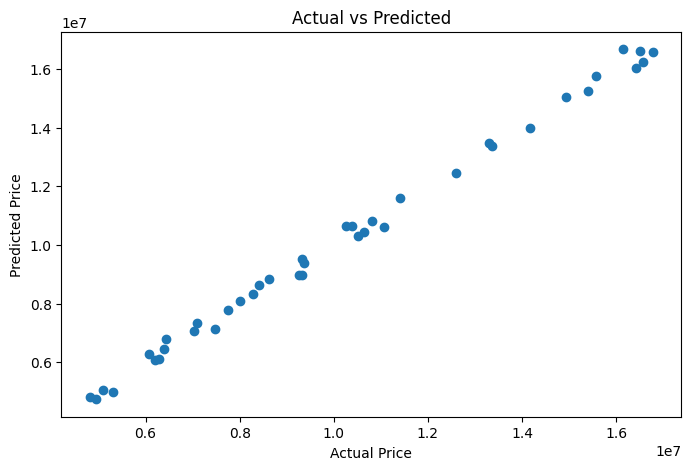

In [59]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

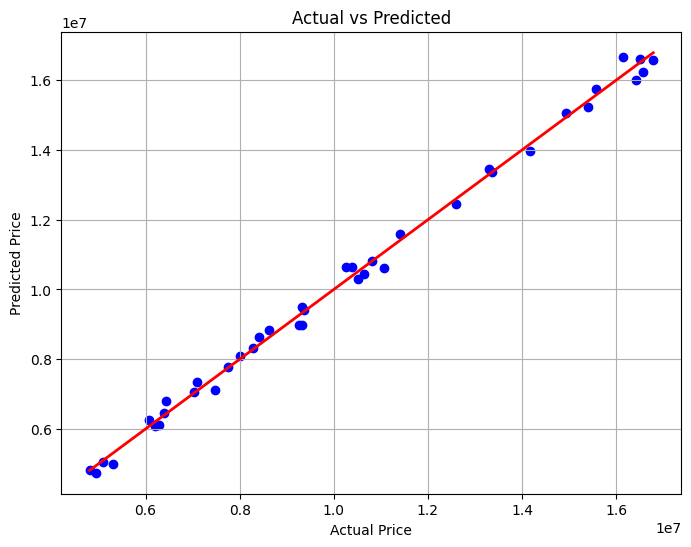

In [62]:
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(y_test.values, y_pred, color='blue')

plt.plot(
    [np.min(y_test), np.max(y_test)],
    [np.min(y_test), np.max(y_test)],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.grid(True)
plt.show()